# ----------------- Navie Bayes Using Sklearn Library -----------------

### What is Naive Bayes? 
__Naive Bayes__ is among one of the most simple and powerful algorithms for classification based on Bayes’ Theorem with an assumption of independence among predictors. Naive Bayes model is easy to build and particularly useful for very large data sets. There are __two parts__ to this algorithm:

- __Naive__
- __Bayes__

The Naive Bayes classifier assumes that the presence of a feature in a class is unrelated to any other feature. Even if these features depend on each other or upon the existence of the other features, all of these properties independently contribute to the probability that a particular fruit is an apple or an orange or a banana and that is why it is known as “Naive”. 


### What is Bayes Theorem?

In Statistics and probability theory, __Bayes__’ theorem describes the probability of an event, based on prior knowledge of conditions that might be related to the event. It serves as a way to figure out conditional probability.

Given a Hypothesis __H__ and evidence __E__, Bayes’ Theorem states that the relationship between the probability of Hypothesis before getting the evidence __P(H)__ and the probability of the hypothesis after getting the evidence __P(H|E)__ is :

<img src="https://d1jnx9ba8s6j9r.cloudfront.net/blog/wp-content/uploads/2018/07/formula-528x90.png">


This relates the probability of the hypothesis before getting the evidence __P(H)__, to the probability of the hypothesis after getting the evidence, __P(H|E)__. For this reason,  is called the __prior probability__, while __P(H|E)__ is called the __posterior probability__. The factor that relates the two, __P(H|E) / P(E)__, is called the __likelihood ratio__. Using these terms, Bayes’ theorem can be rephrased as:


> __“The posterior probability equals the prior probability times the likelihood ratio.”__



### Importing libraries

In [3]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### Import Data set

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/sahdevsaini/Data-Set/main/iris.csv")

In [5]:
df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [6]:
df.shape

(150, 5)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


#### Spliting the dataset in independent and dependent variables

In [8]:
X= df.iloc[:,:4].values
y = df.iloc[:,-1].values

#### Splitting the dataset into the Training set and Test set

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.20,random_state=42)

In [10]:
print("Total no of data rows", len(df),"\nOut of which",len(X_train),"Use for Training","\nand",len(X_test),"Use for Testing")

Total no of data rows 150 
Out of which 120 Use for Training 
and 30 Use for Testing


#### Feature Scaling to bring the variable in a single scale

In [11]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

#### Fitting Naive Bayes Classification to the Training set with linear kernel

In [12]:
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classmethod_model = classifier.fit(X_train,y_train)

In [13]:
predicted_y = classmethod_model.predict(X_test)

In [14]:
Data_compare = pd.DataFrame({"Actual data" : y_test,
                             "Predicted data" : predicted_y
})

In [15]:
Data_compare

,Actual data,Predicted data
0,Versicolor,Versicolor
1,Setosa,Setosa
2,Virginica,Virginica
3,Versicolor,Versicolor
4,Versicolor,Versicolor
5,Setosa,Setosa
6,Versicolor,Versicolor
7,Virginica,Virginica
8,Versicolor,Versicolor
9,Versicolor,Versicolor


In [16]:
from sklearn.metrics import accuracy_score

# Assuming y_test contains the true labels and y_predicted contains the predicted labels

# Calculate accuracy
accuracy = accuracy_score(y_test, predicted_y)

print("Accuracy of the Model:- ", accuracy*100,"%")


Accuracy of the Model:-  100.0 %


In [17]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_recall_curve,roc_auc_score,f1_score

#### Confusion Matrix

In [18]:
cm = confusion_matrix(y_test,predicted_y)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


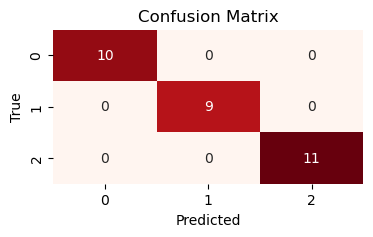

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test, predicted_y)

# Plot confusion matrix
plt.figure(figsize=(4, 2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


#### Precision Recall Curve

In [20]:
f1 = f1_score(y_test, predicted_y, average='micro')
print("F1 Score:", f1)

F1 Score: 1.0
